# Addestramento riconoscimento carte

Notebook dedicato a scontornare le carte dal dataset locale `dataset/carte` (derivando etichette dal nome file) e ad addestrare un modello di classificazione su valore e seme della carta ritagliata.


## Obiettivo

1. Leggere ricorsivamente tutte le immagini `.jpg` in `dataset/carte/*`.
2. Estrarre etichetta dal nome file (`valore_seme_colore`).
3. Scontornare la carta usando la maschera bianca (ispirato allo Step 2 del notebook originale).
4. Salvare i ritagli in `dataset/carte_cropped/<etichetta>/` e costruire il dataset.
5. Addestrare un modello di classificazione sul valore+seme+colore.


In [63]:
import os
from pathlib import Path
from typing import Dict, List, Tuple
from collections import Counter
from tqdm.notebook import tqdm
import sys
import importlib

import cv2
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

module_path = Path().resolve().parent / "blackjack_env"
sys.path.append(str(module_path))
import card_preprocessing as cp
cp = importlib.reload(cp)  # assicura funzioni aggiornate

In [64]:
# Configurazione
DATASET_DIR = Path("carte_aug")  # unico dataset; train/val/test verranno estratti qui
CROPPED_DIR = Path("carte_cropped")
MODEL_DIR = Path("models")

# Risoluzione e parametri condivisi con il notebook di riconoscimento
IMG_HEIGHT, IMG_WIDTH = cp.IMG_HEIGHT, cp.IMG_WIDTH
RANDOM_SEED = 42

# KNN
KNN_N_NEIGHBORS = 5
KNN_WEIGHTS = "distance"

# Maschera/threshold carta (ispirato al kernel più robusto di riconoscimento_carte.ipynb)
MORPH_KERNEL_SIZE = cp.MORPH_KERNEL_SIZE
MORPH_ITERATIONS = cp.MORPH_ITERATIONS

# Filtri per bounding box
CARD_MIN_ASPECT = cp.CARD_MIN_ASPECT
CARD_MAX_ASPECT = cp.CARD_MAX_ASPECT
CARD_MIN_AREA_RATIO = cp.CARD_MIN_AREA_RATIO   # percentuale minima rispetto all'area immagine (≈5%)
CARD_MAX_AREA_RATIO = cp.CARD_MAX_AREA_RATIO

CROPPED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset unico:  {DATASET_DIR.resolve()}")
print(f"Output ritagli: {CROPPED_DIR.resolve()}")

Dataset unico:  C:\Users\Alan\Desktop\Drive_PC_ITS\ITS\2 anno\UF18 VE\Blackjack\dataset\carte_aug
Output ritagli: C:\Users\Alan\Desktop\Drive_PC_ITS\ITS\2 anno\UF18 VE\Blackjack\dataset\carte_cropped


In [65]:
# Parsing etichetta condiviso
parse_card_label = cp.parse_card_label

In [66]:
# Funzioni di preprocessing condivise (alias per leggibilità nel notebook)
create_white_mask = cp.create_white_mask
find_best_card_region = cp.find_best_card_region
apply_affine_cleanup = cp.apply_affine_cleanup
crop_card = cp.crop_card
normalize_card = cp.normalize_card
card_to_vector = cp.card_to_vector

[carte_aug] trovate 864 immagini .jpg


Processing carte_aug:   0%|          | 0/864 [00:00<?, ?it/s]

[carte_aug] Carte ritagliate: 864


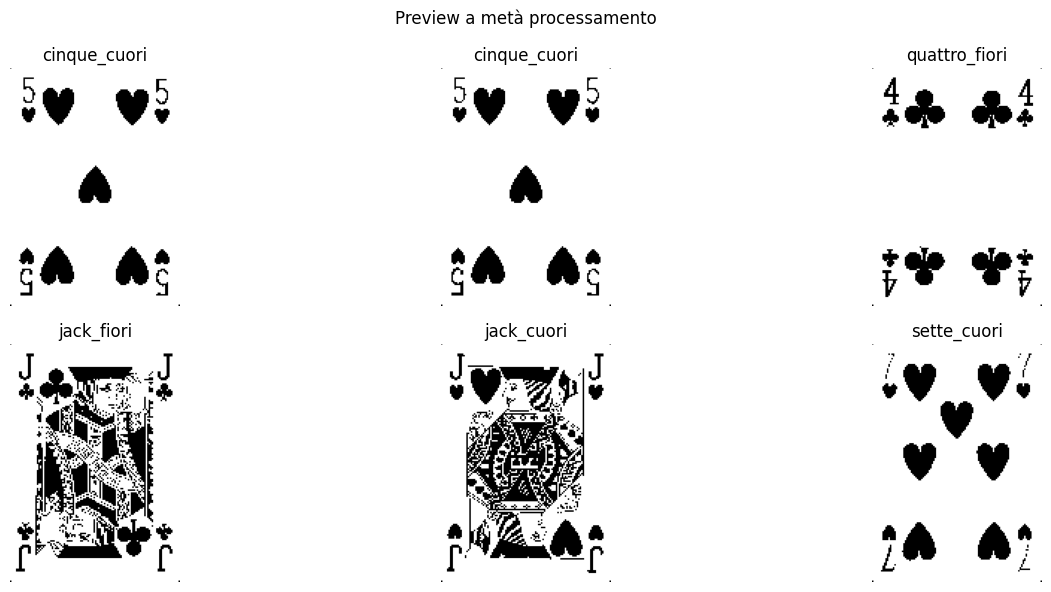

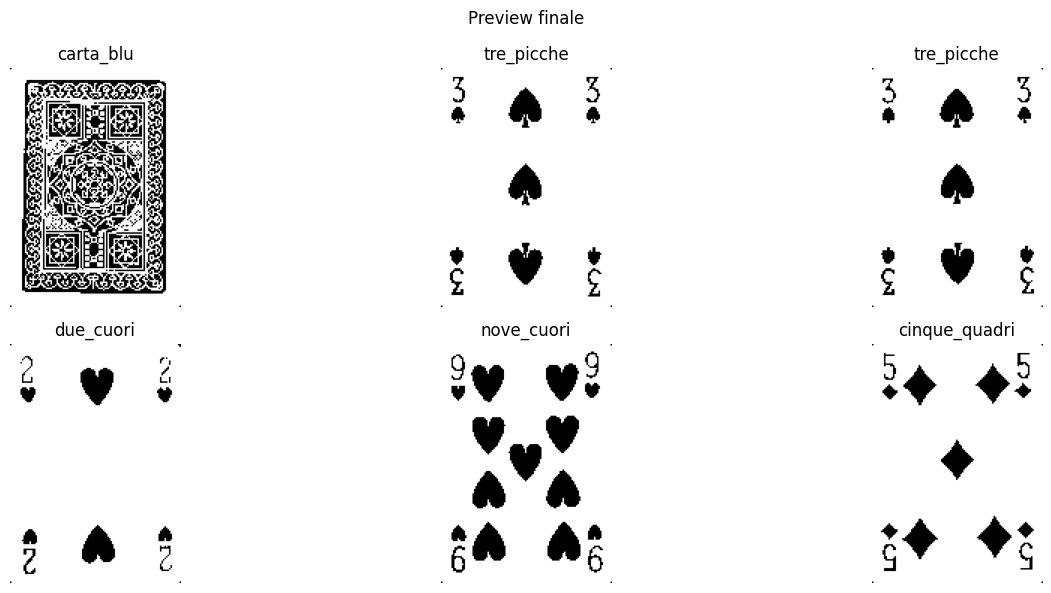

In [67]:
# Ritaglio carte dal dataset unico (train/val/test estratti qui)
def preview_cards(cards: List[Dict], title: str):
    import random
    if not cards:
        return
    sample_count = min(6, len(cards))
    sample_idxs = random.sample(range(len(cards)), sample_count)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(sample_idxs):
        card_bin = cards[idx]["card"]  # (h,w) binario
        plt.subplot(2, 3, i + 1)
        plt.imshow(card_bin, cmap="gray")
        plt.title(cards[idx]["label"])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()


def process_dataset(input_dir: Path, output_dir: Path) -> Tuple[List[Dict], List[str]]:
    image_paths = sorted(input_dir.rglob("*.jpg"))
    total = len(image_paths)
    print(f"[{input_dir.name}] trovate {total} immagini .jpg")

    processed: List[Dict] = []
    failed: List[str] = []
    mid_preview_done = False

    for i, img_path in enumerate(tqdm(image_paths, desc=f"Processing {input_dir.name}")):
        label_info, err = parse_card_label(img_path)
        if err:
            failed.append(f"{img_path.name}: {err}")
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            failed.append(f"{img_path.name}: immagine non leggibile")
            continue

        card, mask, box = crop_card(img)
        if card is None:
            failed.append(f"{img_path.name}: nessun contorno valido")
            continue

        # Normalizza in binario e salva già preprocessato
        card_bin = cp.normalize_card(card, (IMG_HEIGHT, IMG_WIDTH))[:, :, 0]

        out_dir = output_dir / label_info["label"]
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / img_path.name
        cv2.imwrite(str(out_path), card_bin)

        processed.append({
            "src": img_path,
            "out": out_path,
            "label": label_info["label"],
            "value": label_info["value"],
            "suit": label_info["suit"],
            "box": box,
            "mask": mask,
            "card": card_bin,
        })

        # Preview a metà
        if (not mid_preview_done) and (i + 1) >= total // 2:
            preview_cards(processed, "Preview a metà processamento")
            mid_preview_done = True

    # Preview finale
    preview_cards(processed, "Preview finale")

    print(f"[{input_dir.name}] Carte ritagliate: {len(processed)}")
    if failed:
        print(f"[{input_dir.name}] Non elaborate:")
        for msg in failed:
            print(" -", msg)
    return processed, failed

processed_cards, failed_cards = process_dataset(DATASET_DIR, CROPPED_DIR)

In [68]:
# Costruzione dataset per il modello (split unico dal dataset generale)
if not processed_cards:
    raise ValueError("Nessuna carta ritagliata: controlla la fase di preprocessing")

labels = sorted({c["label"] for c in processed_cards})
label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}

# Helper per costruire array
def build_array(cards: List[Dict]) -> Tuple[np.ndarray, np.ndarray]:
    X_arr = np.zeros((len(cards), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)
    y_arr = np.zeros((len(cards),), dtype=np.int32)
    for i, card_info in enumerate(cards):
        card_bin = card_info["card"]  # già binaria e normalizzata (h,w)
        X_arr[i, :, :, 0] = card_bin / 255.0
        y_arr[i] = label_to_idx[card_info["label"]]
    return X_arr, y_arr

X_all, y_all = build_array(processed_cards)
print("Numero classi:", len(labels))

# Garantisce almeno una carta per classe nel train
class_to_idx: Dict[int, List[int]] = {}
for idx, cls in enumerate(y_all):
    class_to_idx.setdefault(int(cls), []).append(idx)

train_fixed = []
pool = []
for cls, idxs in class_to_idx.items():
    rng = np.random.default_rng(RANDOM_SEED + cls)
    rng.shuffle(idxs)
    train_fixed.append(idxs[0])
    pool.extend(idxs[1:])

train_fixed = np.array(train_fixed, dtype=int)
pool = np.array(pool, dtype=int)

val_frac = 0.15
test_frac = 0.15

if len(pool) == 0:
    x_train = X_all[train_fixed]
    y_train = y_all[train_fixed]
    x_val = X_all[0:0]
    y_val = y_all[0:0]
    x_test = X_all[0:0]
    y_test = y_all[0:0]
    print("⚠️ Pool vuoto: tutte le classi avevano 1 sola carta. Nessun val/test creato.")
else:
    pool_labels = y_all[pool]
    pool_size = len(pool)
    n_classes = len(labels)

    val_size_abs = max(int(round(val_frac * pool_size)), n_classes)
    test_size_abs = max(int(round(test_frac * pool_size)), n_classes)
    if val_size_abs + test_size_abs > pool_size:
        surplus = val_size_abs + test_size_abs - pool_size
        val_size_abs = max(n_classes, val_size_abs - surplus)

    stratify_labels = pool_labels if min(Counter(pool_labels).values()) >= 1 else None

    x_pool, y_pool = X_all[pool], y_all[pool]
    x_pool_rest, x_test, y_pool_rest, y_test = train_test_split(
        x_pool, y_pool, test_size=test_size_abs, random_state=RANDOM_SEED, stratify=stratify_labels
    )

    stratify_labels_rest = y_pool_rest if stratify_labels is not None and min(Counter(y_pool_rest).values()) >= 1 else None
    x_train_extra, x_val, y_train_extra, y_val = train_test_split(
        x_pool_rest, y_pool_rest, test_size=val_size_abs, random_state=RANDOM_SEED, stratify=stratify_labels_rest
    )

    x_train = np.concatenate([X_all[train_fixed], x_train_extra], axis=0)
    y_train = np.concatenate([y_all[train_fixed], y_train_extra], axis=0)

print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")

# Flatten per KNN
def flatten_images(x_arr: np.ndarray) -> np.ndarray:
    if x_arr.size == 0:
        return x_arr.reshape((0, IMG_HEIGHT * IMG_WIDTH))
    return x_arr.reshape((x_arr.shape[0], -1))

x_train_flat = flatten_images(x_train)
x_val_flat = flatten_images(x_val)
x_test_flat = flatten_images(x_test)

Numero classi: 54
Train: 620, Val: 122, Test: 122


In [69]:
# Modello KNN
if len(x_train_flat) == 0:
    raise ValueError("Dataset di training vuoto")

knn_model = KNeighborsClassifier(
    n_neighbors=KNN_N_NEIGHBORS,
    weights=KNN_WEIGHTS,
    n_jobs=-1,
)

knn_model.fit(x_train_flat, y_train)

val_acc = accuracy_score(y_val, knn_model.predict(x_val_flat)) if len(x_val_flat) > 0 else float("nan")
test_acc = accuracy_score(y_test, knn_model.predict(x_test_flat)) if len(x_test_flat) > 0 else float("nan")

print(f"Val accuracy: {val_acc:.4f}" if not np.isnan(val_acc) else "Val set assente")
print(f"Test accuracy: {test_acc:.4f}" if not np.isnan(test_acc) else "Test set assente")

if len(y_test) > 0:
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]
    print("Report test:\n", classification_report(y_test, knn_model.predict(x_test_flat), target_names=target_names))

Val accuracy: 1.0000
Test accuracy: 1.0000
Report test:
                 precision    recall  f1-score   support

    asso_cuori       1.00      1.00      1.00         2
    asso_fiori       1.00      1.00      1.00         2
   asso_picche       1.00      1.00      1.00         2
   asso_quadri       1.00      1.00      1.00         2
     carta_blu       1.00      1.00      1.00         2
   carta_rosso       1.00      1.00      1.00         2
  cinque_cuori       1.00      1.00      1.00         2
  cinque_fiori       1.00      1.00      1.00         3
 cinque_picche       1.00      1.00      1.00         2
 cinque_quadri       1.00      1.00      1.00         2
   dieci_cuori       1.00      1.00      1.00         3
   dieci_fiori       1.00      1.00      1.00         2
  dieci_picche       1.00      1.00      1.00         2
  dieci_quadri       1.00      1.00      1.00         2
     due_cuori       1.00      1.00      1.00         3
     due_fiori       1.00      1.00      1.00 

In [70]:
# Analisi errori principali sul test
if len(x_test_flat) > 0:
    y_test_pred = knn_model.predict(x_test_flat)
    mis_idx = np.where(y_test_pred != y_test)[0]
    print(f"Errori: {len(mis_idx)}/{len(y_test)}")
    for i, idx in enumerate(mis_idx[:10]):
        true_lbl = idx_to_label[int(y_test[idx])]
        pred_lbl = idx_to_label[int(y_test_pred[idx])]
        print(f"[{i+1}] true={true_lbl} | pred={pred_lbl}")
else:
    print("Test set assente")

Errori: 0/122


In [71]:
# Salvataggio modello KNN e mappa etichette
knn_path = MODEL_DIR / "card_knn.pkl"
joblib.dump(
    {
        "model": knn_model,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "img_height": IMG_HEIGHT,
        "img_width": IMG_WIDTH,
    },
    knn_path,
)

labels_path = MODEL_DIR / "card_labels.txt"
with open(labels_path, "w", encoding="utf-8") as f:
    for idx, lbl in idx_to_label.items():
        f.write(f"{idx}\t{lbl}\n")

print(f"Modello KNN salvato in: {knn_path}")
print(f"Mappa etichette salvata in: {labels_path}")

Modello KNN salvato in: models\card_knn.pkl
Mappa etichette salvata in: models\card_labels.txt
